## BIO597 Spatial Analysis of Biodiversity Fall 2026


# Simple python data structures - List & Dictionary

## Lists
Lists are one of the fundamental data structures in python. They are optimized for
performance and simplicity. They are similar to vectors/lists in R, while requiring much
less typing for most operations.

In [13]:
# A list of strings
fruits = ["apple", "banana", "cherry"]

# A list of mixed data types
mixed_list = [42, "hello", True, 3.14]

# An empty list
empty_list = []

[42, 'hello', True, 3.14]


In [8]:
# List indexing

# Python lists are 0-indexed. The beginning of the list is element 0 and
# the end of the list is element n-1 (where n is the number of items in the list).

fruits = ["apple", "banana", "cherry"]

print(fruits[0])   # Output: apple
print(fruits[2])   # Output: cherry
print(fruits[-1])  # Output: cherry (counting from the end of the list with negative numbers
print(fruits[-3])

apple
cherry
cherry
apple


In [9]:
# Useful list operations

numbers = [1, 99, 2, 3, 4]

print(len(numbers))     # len() is 'length': 5
print(sorted(numbers))  # Sort the list: [1, 2, 3, 4, 99]
print(numbers[::-1])    # Black magic to reverse the order of items: [4, 3, 2, 99, 1]
numbers.append(42)      # [1, 99, 2, 3, 4, 42]
print(numbers)
print(fruits + numbers)        # join 2 lists together (concatenate): ['apple', 'banana', 'cherry', 1, 99, 2, 3, 4, 42]

5
[1, 2, 3, 4, 99]
[4, 3, 2, 99, 1]
[1, 99, 2, 3, 4, 42]
['apple', 'banana', 'cherry', 1, 99, 2, 3, 4, 42]


In [11]:
# Looping over list items

for n in numbers:
    print(n)
    if n == 1:
        print("hello")

1
hello
99
2
3
4
42


## Dictionaries - Native key/value pairs

A Python dictionary (or dict) is a built-in data structure used to store data in key-value pairs. 
Unlike lists, where elements are accessed by their position (index), dictionary values are accessed 
using a unique key. Dictionaries are ordered (they remember the insertion order), mutable (you can 
change them), and do not allow duplicate keys.

The closest R equivalent is a named list:
```
user <- list(username = "ecology_student", followers = 1500)

# Using double square brackets
print(user[["username"]])  # Output: "coder123"
```

In [12]:
## The python dictionary equivalent of this is:

user = {"username":"ecology_student",
        "followers":1500,
       }

## Access dictionary value associated with a given key
print(user["username"])
print(user["followers"])

## Get a list of keys from a dictionary
print(user.keys())
print(user.values())

ecology_student
1500
dict_keys(['username', 'followers'])
dict_values(['ecology_student', 1500])


In [92]:
## Looping over dictionary items

for key in user:
    # Print the key and the value of the key in the dictionary
    print(key, user[key])

username ecology_student
followers 1500


# Introduction to pygbif and GBIF occurrence data

## Goals for today

This notebook introduces the basic workflow for using Python to fetch biodiversity occurrence records from GBIF.

By the end of this lab you should be able to:

* search for a species name in the GBIF taxonomic backbone
* find the GBIF taxon key for a species
* count available occurrence records
* download a small number of occurrence records
* convert those records into a `GeoDataFrame`
* plot the records on an interactive map

We will use DeKay's brownsnake, *Storeria dekayi*, as the example species.
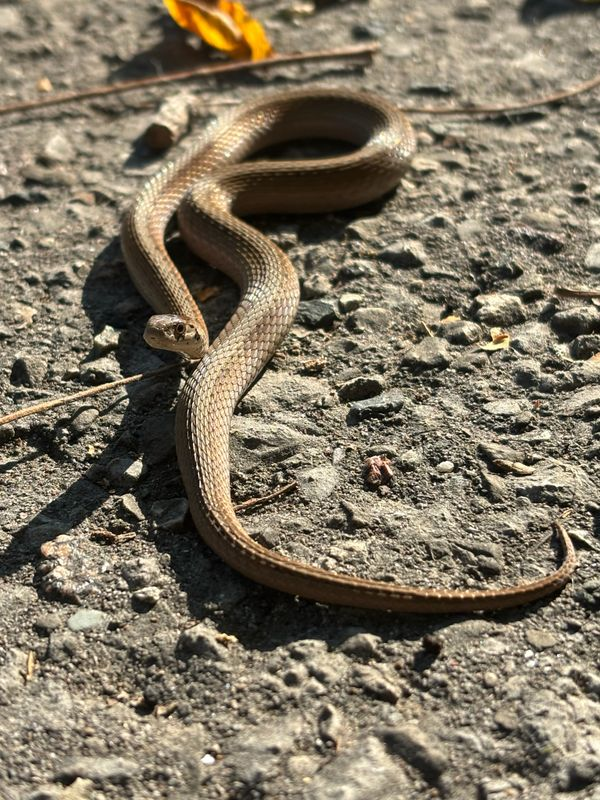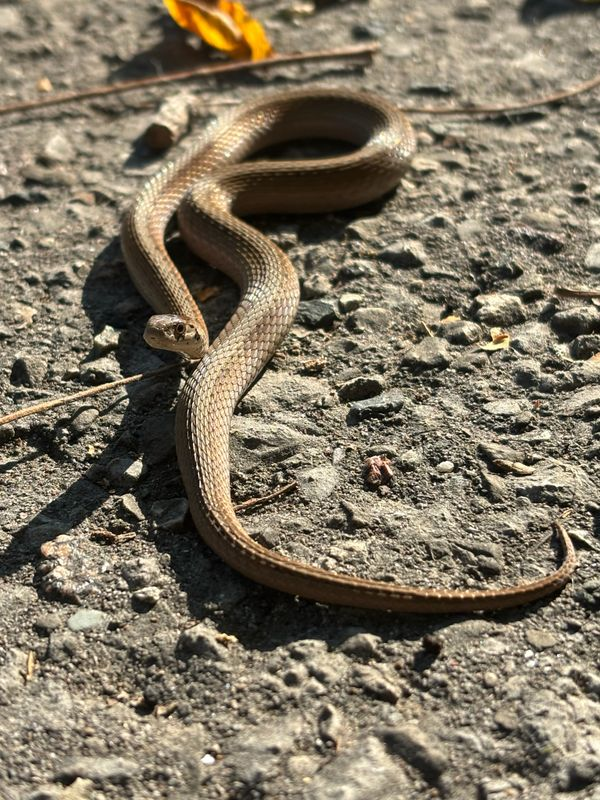

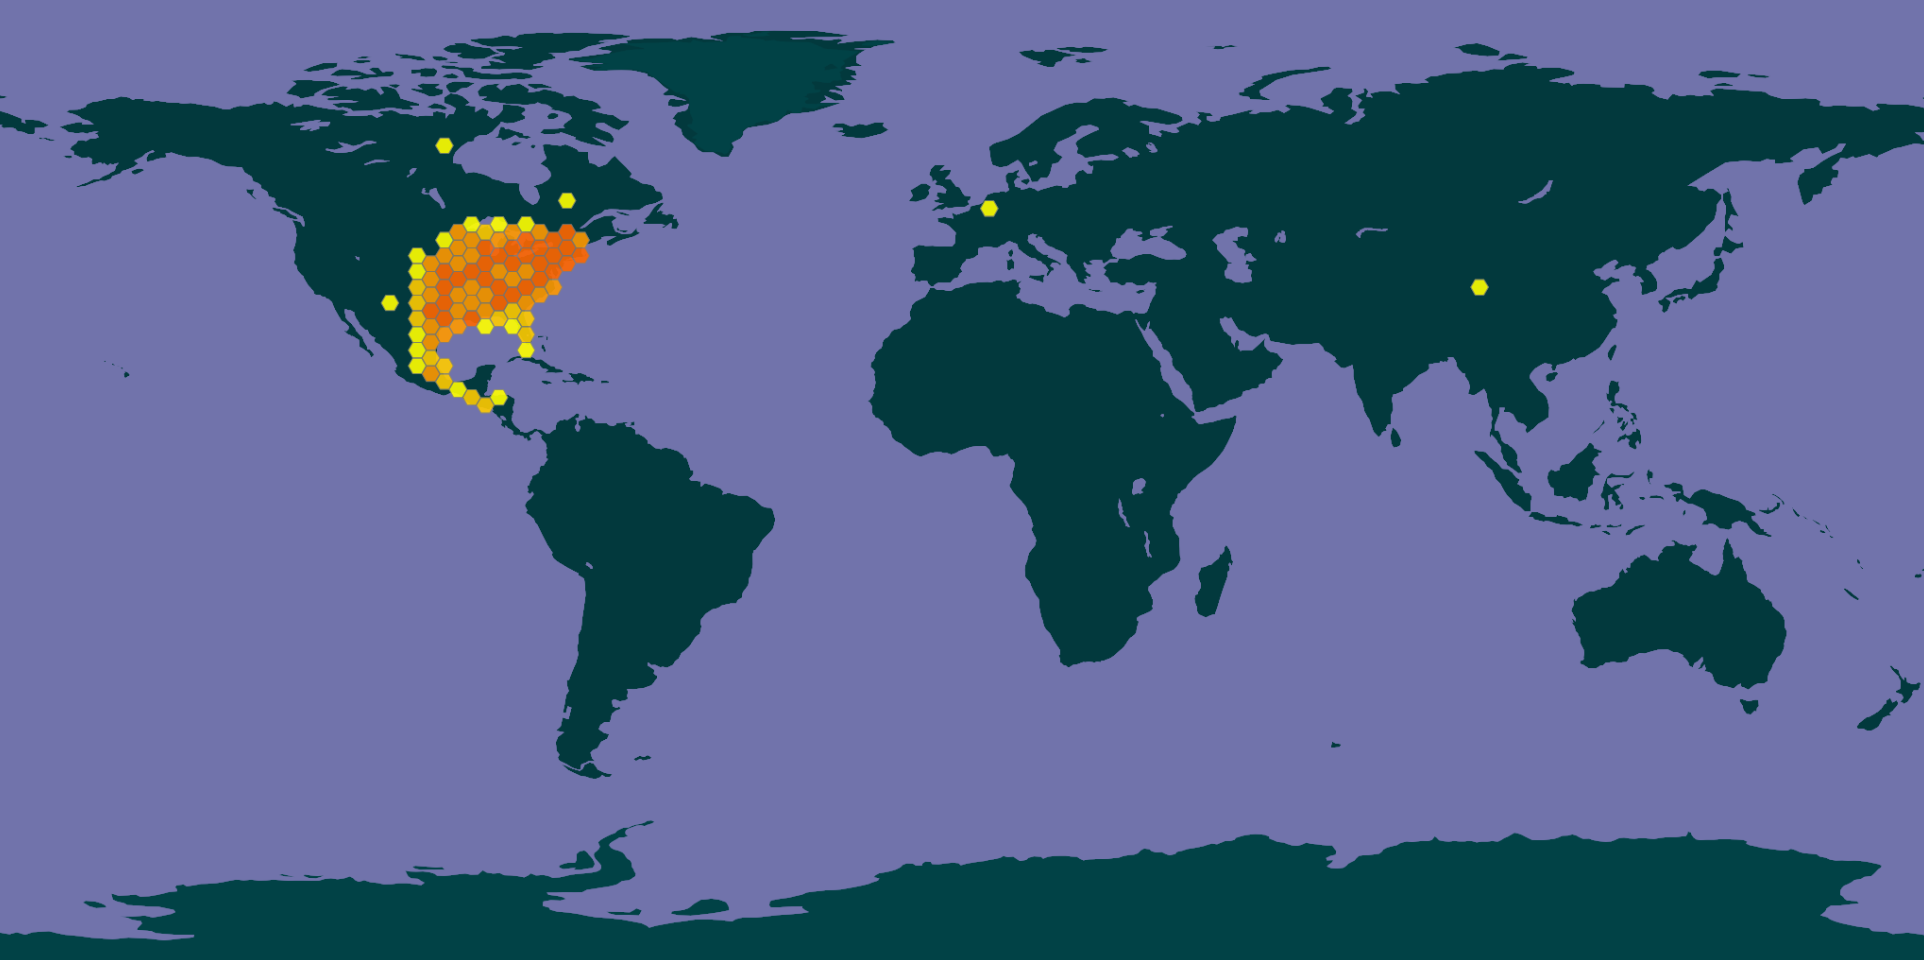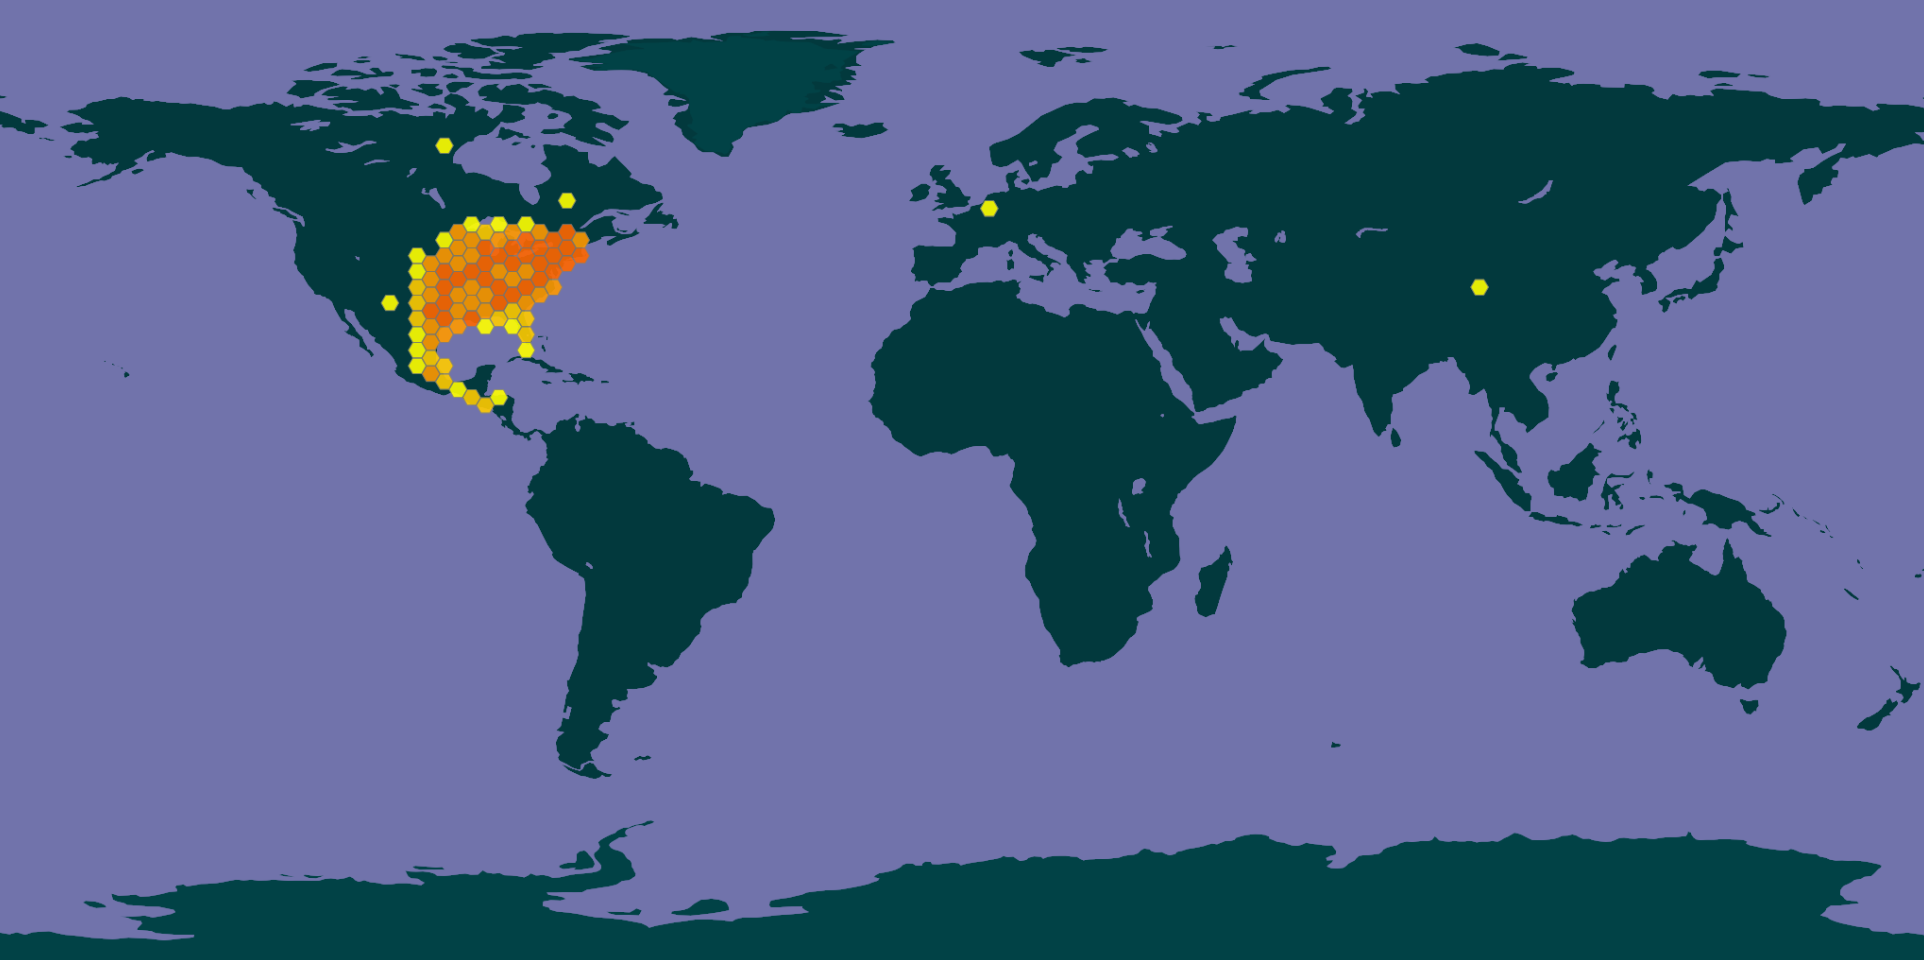

## What is GBIF?

GBIF is the Global Biodiversity Information Facility. It is one of the most important online repositories for biodiversity datay. It brings together biodiversity occurrence records from museums, research collections, community science projects, and other sources.

An occurrence record is usually a record that a species was observed or collected at a particular place and time. Occurrence records are usually georeferenced (i.e. they include decimal latitude and longitude), but not always, and sometimes the latlongs are wrong, so data cleaning is important.

Today we will use `pygbif`[(pygbif homepage)](https://pygbif.readthedocs.io/en/latest/index.html), a Python package that talks to the GBIF API from inside a notebook.


## Prerequisites

If `pygbif` is not already installed, open a terminal and run:

`pip install pygbif`

This lab also uses `geopandas` and `pandas`, which we used in Lab 01.


## 1. Import packages

We will import two parts of `pygbif`:

* `species`, for searching taxonomic names
* `occurrences`, for searching occurrence records

We will also use `pandas` for tables and `geopandas` for spatial data.


In [16]:
from pygbif import species
from pygbif import occurrences as occ
## Importing just the module that you need, you avoid the risk of function name conflicts.
## This allows you to write shorter code bc you don't have to specify the module AND function

import pandas as pd
import geopandas as gpd

## 2. Search for a species name

Before downloading occurrence records, we need GBIF's **taxon key** for the species (called `speciesKey`). The taxon key is a unique numeric identifier used by GBIF. As you might guess, there are taxon keys across different levels of the taxonomic hierarchy (there are `genusKey`, `familyKey`, and so on, up to `kingdomKey`).

`name_suggest()` does a simple search for names that match the text we provide (it's not very smart). This is useful when you are checking spelling or trying to see what GBIF knows about a name.

The funciton may return more than one result, so the output is a _list_ where the zero-th element is the most relevant. We will inspect it first, then pull out the `speciesKey` in the next cell.

Edit: The key for S. dekayi is 9056579

In [24]:
name_results = species.name_suggest(q="Storeria dekayi")
print(type(name_results), len(name_results))

# name_suggest() returns a list of dictionaries in descending order of relevance.

# Look at the zero-th element of name_results, which is itself a dictionary
first_name_result = name_results[0] 

## In a list, you access items using the index
## A dictionary doesnt have the same order that a list does, so you use a key value instead

first_name_result['speciesKey']

<class 'list'> 10


9056579

In [29]:
## Try printing a list of the keys in first_name_result
print(first_name_result.keys())
## first_name_result is a dictionary, so we can call .keys() on it


dict_keys(['key', 'nameKey', 'kingdom', 'phylum', 'family', 'genus', 'species', 'kingdomKey', 'phylumKey', 'classKey', 'familyKey', 'genusKey', 'speciesKey', 'parent', 'parentKey', 'nubKey', 'scientificName', 'canonicalName', 'rank', 'status', 'synonym', 'higherClassificationMap', 'class'])


## 3. Get a more sophisticated match if you aren't sure of the scientific name

[pygbif species module](https://pygbif.readthedocs.io/en/latest/modules/species.html) has another function called `name_lookup()`. This service uses fuzzy lookup so that you can put in partial names and you should get back those things that match


In [30]:
dekayi_lookups = species.name_lookup(q="Storeria d")

print(f"I got {len(dekayi_lookups)} matches for this search.")


I got 6 matches for this search.


## 4. Save the taxon key

The value called `usageKey` is the GBIF taxon key we will use for occurrence searches.


In [32]:
dekayi_key = name_results[0]["speciesKey"]
dekayi_key

9056579

## 5. Count matching occurrence records

Before downloading records, it is useful to ask GBIF how many records match our search.

Here we count records for *Storeria dekayi* that are georeferenced. Georeferenced records have coordinates, which means we can map them.


In [33]:
dekayi_count = occ.count(
    taxonKey=dekayi_key,
    isGeoreferenced=True,
)

dekayi_count

49473

## 6. Fetch up to 100 occurrence records

Now we will fetch occurrence records using `occ.search()`.

For this lab, keep the search small. We will request a maximum of 100 records with `limit=100`.

The GBIF API may have many more matching records than this. Limiting the request keeps the notebook fast and makes the output easier to inspect.


In [34]:
dekayi_records = occ.search(
    taxonKey=dekayi_key,
    hasCoordinate=True,
    hasGeospatialIssue=False,
    year="1900,2000",
    limit=100,
)

print(len(dekayi_records['results']))

# Search records are dictionaries (and they can be large), so look first
# at the available keys. Look at the keys and see if you can guess what
# the associated value of each key means.
dekayi_records.keys()

100


dict_keys(['offset', 'limit', 'endOfRecords', 'count', 'results', 'facets'])

In [54]:
## In this cell try accessing each key in the dekayi_records dictionary
## to verify what the content is and to see if your intuition about it is 

for key in dekayi_records:
     print(key, dekayi_records[key])

## This is not ideal bc it is printing all of that results stuff, which is hard to read

offset 0
limit 100
endOfRecords False
count 4366
results [{'key': 675715501, 'datasetKey': 'b6015b60-6f96-43a9-88e5-2f41854e8f07', 'publishingOrgKey': '2b8e48b0-812d-11de-86fe-b8a03c50a862', 'networkKeys': ['68e8e67a-43e6-44a3-8817-dc0e6b70f973', '99d66b6c-9087-452f-a9d4-f15f2c2d0e7e'], 'installationKey': 'a957a663-2f17-415f-b1c8-5cf6398df8ed', 'hostingOrganizationKey': '2053a639-84c3-4be5-b8bc-96b6d88a976c', 'publishingCountry': 'US', 'protocol': 'EML', 'lastCrawled': '2026-08-31T15:06:11.715+00:00', 'lastParsed': '2026-09-02T02:34:23.416+00:00', 'crawlId': 423, 'extensions': {}, 'basisOfRecord': 'PRESERVED_SPECIMEN', 'occurrenceStatus': 'PRESENT', 'establishmentMeans': 'native', 'classifications': {'7ddf754f-d193-4cc9-b351-99906754a03b': {'usage': {'key': '6ZWD9', 'name': 'Storeria dekayi (Holbrook, 1839)', 'rank': 'SPECIES', 'code': 'ZOOLOGICAL', 'authorship': '(Holbrook, 1839)', 'genericName': 'Storeria', 'specificEpithet': 'dekayi', 'formattedName': '<i>Storeria</i> <i>dekayi</i> 

## 7. Look at one occurrence record

The search result is a dictionary. The actual occurrence records are stored under the `results` key.

Look at the first record before turning all of the records into a table.


In [55]:
dekayi_records["results"][0]

{'key': 675715501,
 'datasetKey': 'b6015b60-6f96-43a9-88e5-2f41854e8f07',
 'publishingOrgKey': '2b8e48b0-812d-11de-86fe-b8a03c50a862',
 'networkKeys': ['68e8e67a-43e6-44a3-8817-dc0e6b70f973',
  '99d66b6c-9087-452f-a9d4-f15f2c2d0e7e'],
 'installationKey': 'a957a663-2f17-415f-b1c8-5cf6398df8ed',
 'hostingOrganizationKey': '2053a639-84c3-4be5-b8bc-96b6d88a976c',
 'publishingCountry': 'US',
 'protocol': 'EML',
 'lastCrawled': '2026-08-31T15:06:11.715+00:00',
 'lastParsed': '2026-09-02T02:34:23.416+00:00',
 'crawlId': 423,
 'extensions': {},
 'basisOfRecord': 'PRESERVED_SPECIMEN',
 'occurrenceStatus': 'PRESENT',
 'establishmentMeans': 'native',
 'classifications': {'7ddf754f-d193-4cc9-b351-99906754a03b': {'usage': {'key': '6ZWD9',
    'name': 'Storeria dekayi (Holbrook, 1839)',
    'rank': 'SPECIES',
    'code': 'ZOOLOGICAL',
    'authorship': '(Holbrook, 1839)',
    'genericName': 'Storeria',
    'specificEpithet': 'dekayi',
    'formattedName': '<i>Storeria</i> <i>dekayi</i> (Holbrook, 18

## 8. Convert the records to a table

`pandas.DataFrame()` turns the list of occurrence records into a table.

This table has many columns. We will keep a small set of columns that are useful for a first map.


In [56]:
dekayi_df = pd.DataFrame(dekayi_records["results"])

dekayi_df.head()

,key,datasetKey,publishingOrgKey,networkKeys,installationKey,hostingOrganizationKey,publishingCountry,protocol,lastCrawled,lastParsed,...,scientificNameID,namePublishedInYear,nameAccordingTo,verbatimElevation,informationWithheld,parentNameUsage,habitat,http://unknown.org/dateLastUpdated,acceptedNameUsage,originalNameUsage
0,675715501,b6015b60-6f96-43a9-88e5-2f41854e8f07,2b8e48b0-812d-11de-86fe-b8a03c50a862,"[68e8e67a-43e6-44a3-8817-dc0e6b70f973, 99d66b6...",a957a663-2f17-415f-b1c8-5cf6398df8ed,2053a639-84c3-4be5-b8bc-96b6d88a976c,US,EML,2026-08-31T15:06:11.715+00:00,2026-09-02T02:34:23.416+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,894771778,ad0d4b56-c620-45a5-9152-7a0da3bd48e8,609765e0-4ce8-11db-b80e-b8a03c50a862,"[68e8e67a-43e6-44a3-8817-dc0e6b70f973, 99d66b6...",9ec56080-ef8d-488a-af71-1e2de5ed7bbc,609765e0-4ce8-11db-b80e-b8a03c50a862,US,EML,2026-09-10T17:04:32.375+00:00,2026-09-10T17:05:40.483+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,894771803,ad0d4b56-c620-45a5-9152-7a0da3bd48e8,609765e0-4ce8-11db-b80e-b8a03c50a862,"[68e8e67a-43e6-44a3-8817-dc0e6b70f973, 99d66b6...",9ec56080-ef8d-488a-af71-1e2de5ed7bbc,609765e0-4ce8-11db-b80e-b8a03c50a862,US,EML,2026-09-10T17:04:32.375+00:00,2026-09-10T17:05:40.488+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1931543266,d5fafa95-7de2-48c0-bf10-3480bcca4a2b,69e7f900-ed5b-11dd-ac7e-b8a03c50a862,"[68e8e67a-43e6-44a3-8817-dc0e6b70f973, 8e30b68...",a957a663-2f17-415f-b1c8-5cf6398df8ed,2053a639-84c3-4be5-b8bc-96b6d88a976c,US,EML,2026-08-31T13:05:33.593+00:00,2026-09-02T08:02:43.376+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2819898487,852628c6-f762-11e1-a439-00145eb45e9a,3c6ad080-bdbe-11da-ac59-b8a03c50a862,"[68e8e67a-43e6-44a3-8817-dc0e6b70f973, 8e30b68...",db7e3f20-3966-4c50-b747-4dfc7b3d3874,3c6ad080-bdbe-11da-ac59-b8a03c50a862,US,EML,2026-09-11T08:13:34.992+00:00,2026-09-11T08:17:41.091+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Keep the columns we need

GBIF occurrence records can contain a lot of information. For now, keep only a few columns so the table is easier to read.


In [57]:
dekayi_df = dekayi_df[
    ["key", "scientificName", "decimalLongitude", "decimalLatitude", "year", "basisOfRecord", "countryCode"]
]

dekayi_df.head()

,key,scientificName,decimalLongitude,decimalLatitude,year,basisOfRecord,countryCode
0,675715501,"Storeria dekayi (Holbrook, 1839)",-96.465278,30.646667,2000,PRESERVED_SPECIMEN,US
1,894771778,"Storeria dekayi (Holbrook, 1839)",-97.494606,35.015167,2000,PRESERVED_SPECIMEN,US
2,894771803,"Storeria dekayi (Holbrook, 1839)",-97.564911,34.971569,2000,PRESERVED_SPECIMEN,US
3,1931543266,"Storeria dekayi (Holbrook, 1839)",-79.703800,34.366000,2000,PRESERVED_SPECIMEN,US
4,2819898487,"Storeria dekayi (Holbrook, 1839)",-98.026110,27.541320,2000,PRESERVED_SPECIMEN,US


## 10. Convert the table to a GeoDataFrame

This step should look familiar from Lab 01.

GBIF uses `decimalLongitude` and `decimalLatitude` for coordinate columns. We use those columns to create point geometry.


In [58]:
dekayi_gdf = gpd.GeoDataFrame(
    dekayi_df,
    geometry=gpd.points_from_xy(dekayi_df["decimalLongitude"], dekayi_df["decimalLatitude"]),
    crs="EPSG:4326",
)

dekayi_gdf.head()

,key,scientificName,decimalLongitude,decimalLatitude,year,basisOfRecord,countryCode,geometry
0,675715501,"Storeria dekayi (Holbrook, 1839)",-96.465278,30.646667,2000,PRESERVED_SPECIMEN,US,POINT (-96.46528 30.64667)
1,894771778,"Storeria dekayi (Holbrook, 1839)",-97.494606,35.015167,2000,PRESERVED_SPECIMEN,US,POINT (-97.49461 35.01517)
2,894771803,"Storeria dekayi (Holbrook, 1839)",-97.564911,34.971569,2000,PRESERVED_SPECIMEN,US,POINT (-97.56491 34.97157)
3,1931543266,"Storeria dekayi (Holbrook, 1839)",-79.703800,34.366000,2000,PRESERVED_SPECIMEN,US,POINT (-79.7038 34.366)
4,2819898487,"Storeria dekayi (Holbrook, 1839)",-98.026110,27.541320,2000,PRESERVED_SPECIMEN,US,POINT (-98.02611 27.54132)


## 11. Plot the records

Use `.explore()` to make an interactive map of the GBIF records.


In [59]:
dekayi_gdf.explore()

## 12. Color the points by record type

The `basisOfRecord` column describes the general kind of occurrence record, such as a preserved specimen or a human observation.

Coloring by this column lets us see whether different kinds of records have different spatial patterns.


In [60]:
dekayi_gdf.explore(column="year", cmap="Blues")

## 13. Count records by year

GBIF records often include a `year` column. A quick count by year can show whether the downloaded records are mostly old, recent, or spread across time.


In [61]:
dekayi_gdf.groupby("year").size()

year
1997    22
1998    24
1999    25
2000    29
dtype: int64

In [62]:
## 14. Select and plot only samples from the US

In [63]:
# Select the 'countryCode' column
dekayi_gdf["countryCode"]

0     US
1     US
2     US
3     US
4     US
      ..
95    US
96    CA
97    MX
98    US
99    US
Name: countryCode, Length: 100, dtype: str

In [68]:
dekayi_gdf.groupby("countryCode").size()

countryCode
CA     4
MX     6
US    90
dtype: int64

In [69]:
# Which values in this column equal "United States of America"
## "US"
# Asking which columns equal a particular value returns a 'bitmask' of True/False values
dekayi_gdf["countryCode"] == "US"

0      True
1      True
2      True
3      True
4      True
      ...  
95     True
96    False
97    False
98     True
99     True
Name: countryCode, Length: 100, dtype: bool

In [70]:
# Use this bitmask (True/False) values to select only the 'True' columns
# Capture this new subset geodataframe in a new variable
us_dekayi_gdf = dekayi_gdf[dekayi_gdf["countryCode"] == "US"]

# Pretty cool!
us_dekayi_gdf.explore()

## 15. A quick note about citations

GBIF data should be cited when used in reports, publications, or assignments. In this lab we used a small API search rather than a formal GBIF download with a DOI.

For later projects, we will talk about GBIF downloads, citations, and reproducibility in more detail.


### Practice submitting your work to your github

Now that you have run through this exercise, practice submitting your notebook code to your class repo.

Open a terminal window and run these commands to add, commit, and push your notebook:

```
# Go to the labs directory in the course repo
cd ~/BIO597-SpatialBiodiversity/docs/labs

# Add your changed lab
git add Lab02-pygbif.ipynb
git commit -m 'Finished Lab02'
git push
```
